<a href="https://colab.research.google.com/github/Prerna-Karle/genai-workshop/blob/main/Unit_Code_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

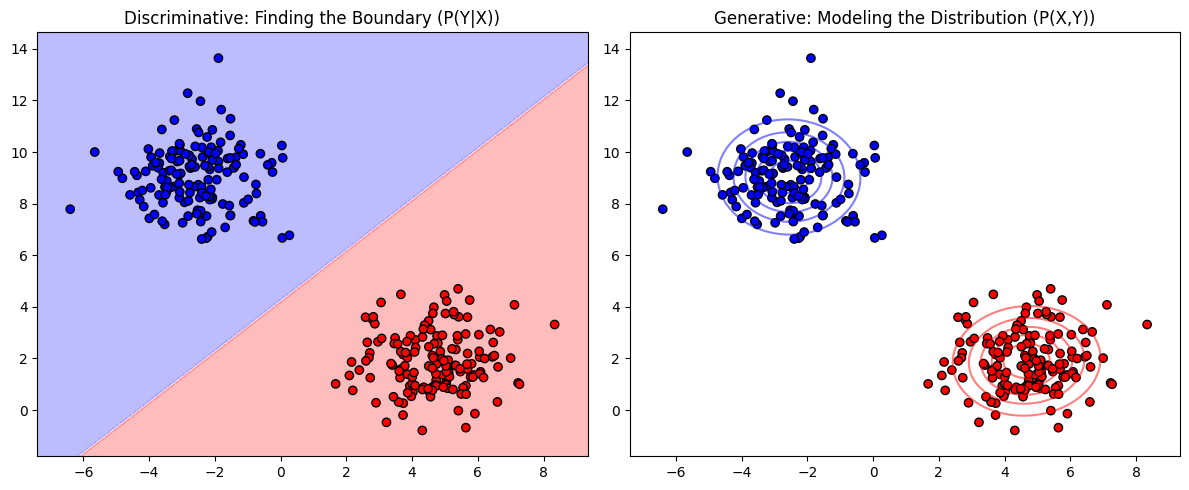

In [1]:
#Unit 1

!pip install transformers torch matplotlib seaborn scikit-learn numpy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture

# 1. Generate synthetic 2D data (two classes)
X, y = make_blobs(n_samples=300, centers=2, cluster_std=1.2, random_state=42)

# 2. Train Discriminative Model (Logistic Regression)
disc_model = LogisticRegression().fit(X, y)

# 3. Train Generative Model (Gaussian Mixture Model on just one class for visualization)
gen_model_class0 = GaussianMixture(n_components=1).fit(X[y == 0])
gen_model_class1 = GaussianMixture(n_components=1).fit(X[y == 1])

# 4. Visualization Setup
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Discriminative (Decision Boundary)
Z_disc = disc_model.predict(grid).reshape(xx.shape)
ax1.contourf(xx, yy, Z_disc, alpha=0.3, cmap='bwr')
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
ax1.set_title("Discriminative: Finding the Boundary (P(Y|X))")

# Plot Generative (Density / Distribution)
Z_gen0 = np.exp(gen_model_class0.score_samples(grid)).reshape(xx.shape)
Z_gen1 = np.exp(gen_model_class1.score_samples(grid)).reshape(xx.shape)
ax2.contour(xx, yy, Z_gen0, levels=5, colors='blue', alpha=0.5)
ax2.contour(xx, yy, Z_gen1, levels=5, colors='red', alpha=0.5)
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
ax2.set_title("Generative: Modeling the Distribution (P(X,Y))")

plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


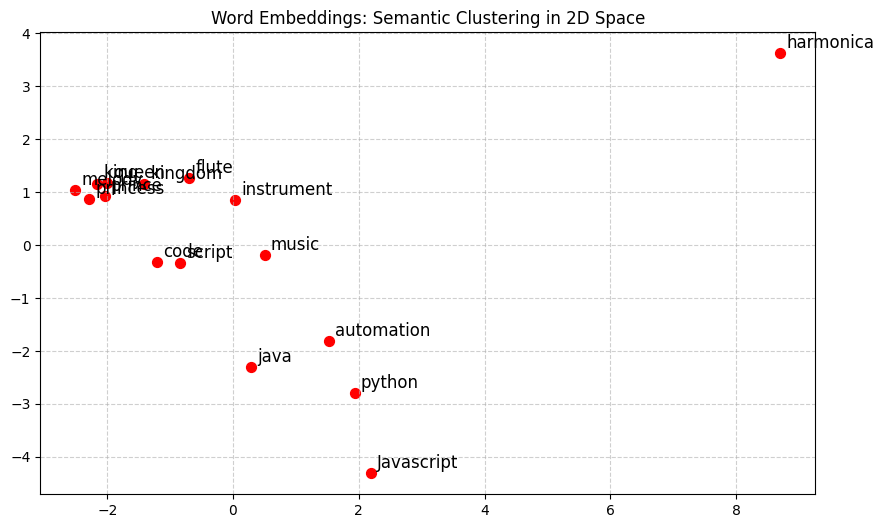

[[-2.15636232  1.15928986]
 [-1.99852914  1.17270458]
 [-2.04070866  0.93147887]
 [-2.29352498  0.87363066]
 [-1.41593049  1.15527391]
 [ 1.93503992 -2.80008602]
 [ 0.28073245 -2.29877377]
 [-0.8497523  -0.34112422]
 [ 1.52604365 -1.80763802]
 [-1.20925745 -0.32327349]
 [ 2.18776417 -4.31061504]
 [-0.70070942  1.2636029 ]
 [ 0.50427255 -0.18753283]
 [-2.50533857  1.04258219]
 [ 0.03767435  0.84736921]
 [ 8.69858625  3.6231112 ]]


In [3]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import BertModel, BertTokenizer

# Load pre-trained BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# A mix of concepts: Royalty, Tech/Automation, and Music (Flute)
words = [
    "king", "queen", "prince", "princess", "kingdom",
    "python", "java", "script", "automation", "code", "Javascript",
    "flute", "music", "melody", "instrument", "harmonica"
]

# Extract embeddings for each word
embeddings = []
with torch.no_grad():
    for word in words:
        inputs = tokenizer(word, return_tensors="pt")
        outputs = model(**inputs)
        # Take the embedding of the [CLS] token as the word representation
        word_vec = outputs.last_hidden_state[0, 0, :].numpy()
        embeddings.append(word_vec)

# Compress 768 dimensions to 2 dimensions for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], color='red', s=50)

for i, word in enumerate(words):
    plt.annotate(word, (reduced_embeddings[i, 0] + 0.1, reduced_embeddings[i, 1] + 0.1), fontsize=12)

plt.title("Word Embeddings: Semantic Clustering in 2D Space")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(reduced_embeddings)

In [4]:
print(embeddings)

[array([-1.31842285e-01,  1.99664846e-01,  5.93248345e-02,  8.05157125e-02,
       -4.25272696e-02, -9.09169093e-02,  2.89855838e-01,  7.02190995e-02,
       -1.74789101e-01, -2.34985262e-01, -7.89091662e-02,  4.34499308e-02,
       -3.50873470e-02,  2.33909428e-01,  2.86232054e-01,  6.70205131e-02,
       -1.90823257e-01,  6.66068345e-02,  3.29980433e-01, -4.61915463e-01,
       -5.04732095e-02, -1.24035448e-01, -1.04742512e-01, -2.04168454e-01,
        1.21556789e-01, -9.22461972e-02, -4.62523624e-02, -3.12232599e-03,
        3.38188633e-02,  1.52952224e-01,  3.90301198e-02,  2.50140697e-01,
       -1.91526622e-01,  1.52124807e-01, -8.37575495e-02, -5.63806072e-02,
        3.59423682e-02, -8.47678259e-02, -3.33019160e-02,  7.54867308e-03,
        1.59110442e-01, -6.90210164e-02,  1.86609000e-01, -3.84036936e-02,
       -1.22376099e-01, -2.96522945e-01, -1.57619023e+00, -9.47436839e-02,
       -7.00378045e-02, -1.18898474e-01,  1.65515155e-01,  2.40328044e-01,
        4.32395376e-02, 

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Enter a prompt:The future of artificial intelligence is


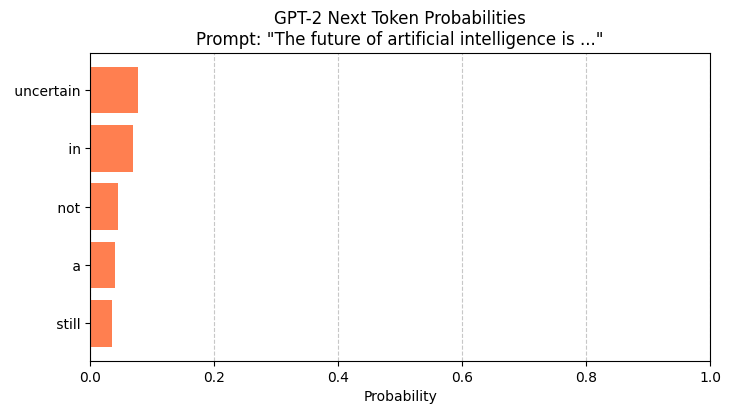

In [5]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# Load GPT-2
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')

prompt = input('Enter a prompt:')
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

# Grab the logits (raw scores) for the very last token in the sequence
next_token_logits = outputs.logits[0, -1, :]

# Convert raw scores to probabilities using Softmax
probabilities = F.softmax(next_token_logits, dim=-1)

# Get the top 5 most likely next tokens
top_k = 5
top_probs, top_indices = torch.topk(probabilities, top_k)

top_probs = top_probs.numpy()
# Decode the token IDs back into actual text words
top_words = [tokenizer.decode([idx.item()]) for idx in top_indices]

# Visualization
plt.figure(figsize=(8, 4))
plt.barh(top_words[::-1], top_probs[::-1], color='coral')
plt.title(f'GPT-2 Next Token Probabilities\nPrompt: "{prompt} ..."')
plt.xlabel("Probability")
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [6]:
#Unit 2
!pip install -q transformers gradio networkx matplotlib scikit-learn
import gradio as gr
from transformers import pipeline

# Load a lightweight text generator to run instantly in Colab
generator = pipeline('text-generation', model='distilgpt2')

def generate_script(topic, temperature, max_len):
    # This is the "Prompt Engineering" structural wrapper
    prompt = f"Short-form video script about {topic}:\n\n[Visual Sequence 1:"

    out = generator(
        prompt,
        max_length=max_len,
        temperature=temperature,
        num_return_sequences=1,
        truncation=True
    )
    return out[0]['generated_text']

# Visual UI for testing prompt parameters
iface = gr.Interface(
    fn=generate_script,
    inputs=[
        gr.Textbox(label="Video Topic", value="Cinematic lighting setups"),
        gr.Slider(0.1, 2.0, value=0.7, label="Temperature (Lower = strict, Higher = random)"),
        gr.Slider(20, 150, value=75, step=5, label="Max Token Length")
    ],
    outputs=gr.Textbox(label="Generated Output", lines=5),
    title="Prompt Engineering & Generation",
    description="Adjust the temperature to see how the model transitions from highly predictable to highly creative."
)
iface.launch(debug=False)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4916a74a7d9202e164.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [7]:
#Unit 2
!pip install -q transformers gradio networkx matplotlib scikit-learn
import gradio as gr
from transformers import pipeline

# Load a lightweight text generator to run instantly in Colab
generator = pipeline('text-generation', model='distilgpt2')

def generate_script(topic, temperature, max_len):
    # This is the "Prompt Engineering" structural wrapper
    prompt = f"provide details about {topic}"

    out = generator(
        prompt,
        max_length=max_len,
        temperature=temperature,
        num_return_sequences=1,
        truncation=True
    )
    return out[0]['generated_text']

# Visual UI for testing prompt parameters
iface = gr.Interface(
    fn=generate_script,
    inputs=[
        gr.Textbox(label="Topic", value="LLMs"),
        gr.Slider(0.1, 2.0, value=0.7, label="Temperature (Lower = strict, Higher = random)"),
        gr.Slider(20, 150, value=75, step=5, label="Max Token Length")
    ],
    outputs=gr.Textbox(label="Generated Output", lines=5),
    title="Prompt Engineering & Generation",
    description="Adjust the temperature to see how the model transitions from highly predictable to highly creative."
)
iface.launch(debug=False)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1a8768bb4b7b15fce6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
#Unit 2
!pip install -q transformers gradio networkx matplotlib scikit-learn
import gradio as gr
from transformers import pipeline

# Load a lightweight text generator to run instantly in Colab
generator = pipeline('text-generation', model='distilgpt2')

def generate_script(topic, temperature, max_len):
    # This is the "Prompt Engineering" structural wrapper
    prompt = f"give a solution for {topic}"

    out = generator(
        prompt,
        max_length=max_len,
        temperature=temperature,
        num_return_sequences=1,
        truncation=True
    )
    return out[0]['generated_text']

# Visual UI for testing prompt parameters
iface = gr.Interface(
    fn=generate_script,
    inputs=[
        gr.Textbox(label="Topic", value="LLMs"),
        gr.Slider(0.1, 2.0, value=0.7, label="Temperature (Lower = strict, Higher = random)"),
        gr.Slider(20, 150, value=75, step=5, label="Max Token Length")
    ],
    outputs=gr.Textbox(label="Generated Output", lines=5),
    title="Prompt Engineering & Generation",
    description="Adjust the temperature to see how the model transitions from highly predictable to highly creative."
)
iface.launch(debug=False)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c219cb23bfcd67fb4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [10]:
#Unit 2
!pip install -q transformers gradio networkx matplotlib scikit-learn
import gradio as gr
from transformers import pipeline

# Load a lightweight text generator to run instantly in Colab
generator = pipeline('text-generation', model='distilgpt2')

def generate_script(topic, temperature, max_len):
    # This is the "Prompt Engineering" structural wrapper
    prompt = f"provide a detailed business report based on the following P&L statements {topic}"

    out = generator(
        prompt,
        max_length=max_len,
        temperature=temperature,
        num_return_sequences=1,
        truncation=True
    )
    return out[0]['generated_text']

# Visual UI for testing prompt parameters
iface = gr.Interface(
    fn=generate_script,
    inputs=[
        gr.Textbox(label="Topic", value="Business Report"),
        gr.Slider(0.1, 2.0, value=0.7, label="Temperature (Lower = strict, Higher = random)"),
        gr.Slider(20, 150, value=75, step=5, label="Max Token Length")
    ],
    outputs=gr.Textbox(label="Generated Output", lines=5),
    title="Prompt Engineering & Generation",
    description="Adjust the temperature to see how the model transitions from highly predictable to highly creative."
)
iface.launch(debug=False)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9454fd0bc858bba7a7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [14]:
!pip install -q transformers torch gradio

import gradio as gr
from transformers import pipeline

# Load GPT-2 text generation pipeline
generator = pipeline(
    "text-generation",
    model="gpt2",
    tokenizer="gpt2"
)

def grocery_list(topic, temperature, max_tokens):

    prompt = f"""
You are an expert chef.

Dish: {topic}

List ONLY the grocery items required for this dish.

Groceries:
-"""

    result = generator(
        prompt,
        max_new_tokens=int(max_tokens),
        temperature=float(temperature),
        do_sample=True,
        pad_token_id=50256
    )[0]["generated_text"]

    # Remove prompt
    output = result.replace(prompt, "").strip()

    return output


with gr.Blocks(title="Prompt Engineering & Generation") as demo:

    gr.Markdown(
        "# Prompt Engineering & Generation\n"
        "Adjust the temperature to see how the model transitions from highly predictable to highly creative."
    )

    with gr.Row():

        with gr.Column():

            topic = gr.Textbox(
                label="Topic",
                placeholder="Example: Paneer Butter Masala"
            )

            temperature = gr.Slider(
                0.1,
                2.0,
                value=0.7,
                step=0.1,
                label="Temperature"
            )

            max_tokens = gr.Slider(
                20,
                150,
                value=75,
                step=5,
                label="Max Token Length"
            )

            with gr.Row():
                clear = gr.Button("Clear")
                submit = gr.Button("Submit", variant="primary")

        with gr.Column():

            output = gr.Textbox(
                label="Generated Output",
                lines=18
            )

    submit.click(
        grocery_list,
        inputs=[topic, temperature, max_tokens],
        outputs=output
    )

    clear.click(
        lambda: ("", ""),
        outputs=[topic, output]
    )

demo.launch()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3da55084c380cb4a5d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
